# Assignment 10: Ising Model for the Traveling Salesman Problem

## 1. Problem Definition

We solve a **small 4-city TSP** using an Ising model. The salesman must visit each city exactly once and return to the starting city, minimizing total travel cost.

### City Layout and Cost Matrix

```
        10
  A --------- B
  |  \      / |
  |   \ 25 /  |
 15    \  / 20 |35
  |    / \     |
  |   / 30\   |
  C --------- D
        12
```

| From\To | A  | B  | C  | D  |
|---------|----|----|----|----|
| A       | 0  | 10 | 15 | 25 |
| B       | 10 | 0  | 20 | 35 |
| C       | 15 | 20 | 0  | 12 |
| D       | 25 | 35 | 12 | 0  |

The optimal tour is: **A → B → C → D → A** with cost 10 + 20 + 12 + 25 = **67**  
(or equivalently A → D → C → B → A = 25 + 12 + 20 + 10 = 67)

## 2. Ising Model Energy Function and Binary Variables

### Binary Variables

We define binary variables $x_{i,p} \in \{0, 1\}$ where:
- $i$ = city index (0=A, 1=B, 2=C, 3=D)
- $p$ = position in the tour (0, 1, 2, 3)
- $x_{i,p} = 1$ means city $i$ is visited at position $p$ in the tour

This gives us $N \times N = 4 \times 4 = 16$ binary variables.

### Energy Function (QUBO Formulation)

The total energy (cost function) to minimize is:

$$H = H_{\text{cost}} + A \cdot H_{\text{row}} + A \cdot H_{\text{col}}$$

**Travel cost term** — encourages short tours:

$$H_{\text{cost}} = \sum_{i=0}^{N-1} \sum_{j=0}^{N-1} d_{ij} \sum_{p=0}^{N-1} x_{i,p} \cdot x_{j,(p+1)\bmod N}$$

**Row constraint** — each city is visited exactly once:

$$H_{\text{row}} = \sum_{i=0}^{N-1} \left(1 - \sum_{p=0}^{N-1} x_{i,p}\right)^2$$

**Column constraint** — each position has exactly one city:

$$H_{\text{col}} = \sum_{p=0}^{N-1} \left(1 - \sum_{i=0}^{N-1} x_{i,p}\right)^2$$

$A$ is a penalty weight chosen large enough to enforce constraints (we use $A = 100$, well above the maximum possible tour cost).

## 3. Implementation: Simulated Annealing on the Ising Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# City names and distance matrix
city_names = ['A', 'B', 'C', 'D']
N = len(city_names)

dist = np.array([
    [0,  10, 15, 25],
    [10,  0, 20, 35],
    [15, 20,  0, 12],
    [25, 35, 12,  0]
])

A_penalty = 100  # constraint penalty weight


def energy(x, dist, A_penalty):
    """Compute total energy of state x (NxN binary matrix)."""
    N = x.shape[0]

    # Travel cost: sum d_ij * x_{i,p} * x_{j,(p+1)%N}
    h_cost = 0
    for p in range(N):
        p_next = (p + 1) % N
        for i in range(N):
            for j in range(N):
                h_cost += dist[i, j] * x[i, p] * x[j, p_next]

    # Row constraint: each city visited exactly once
    h_row = sum((1 - np.sum(x[i, :])) ** 2 for i in range(N))

    # Column constraint: each position has exactly one city
    h_col = sum((1 - np.sum(x[:, p])) ** 2 for p in range(N))

    return h_cost + A_penalty * (h_row + h_col)


def decode_tour(x):
    """Decode binary matrix to tour ordering."""
    N = x.shape[0]
    tour = []
    for p in range(N):
        cities_at_p = np.where(x[:, p] == 1)[0]
        if len(cities_at_p) == 1:
            tour.append(cities_at_p[0])
        else:
            return None  # invalid
    return tour


def tour_cost(tour, dist):
    """Compute actual tour cost."""
    N = len(tour)
    return sum(dist[tour[i], tour[(i + 1) % N]] for i in range(N))


def simulated_annealing(dist, A_penalty, T_start=10.0, T_end=0.01,
                        cooling=0.9995, max_steps=100000, seed=None):
    """Simulated annealing to minimize the Ising energy."""
    rng = np.random.RandomState(seed)
    N = dist.shape[0]

    # Random initial state: random permutation matrix
    x = np.zeros((N, N), dtype=int)
    perm = rng.permutation(N)
    for p in range(N):
        x[perm[p], p] = 1

    current_e = energy(x, dist, A_penalty)
    best_x = x.copy()
    best_e = current_e
    energies = [current_e]

    T = T_start
    for step in range(max_steps):
        # Propose a flip: randomly pick a cell and toggle it
        i, p = rng.randint(0, N), rng.randint(0, N)
        x[i, p] = 1 - x[i, p]
        new_e = energy(x, dist, A_penalty)
        delta = new_e - current_e

        # Accept or reject
        if delta < 0 or rng.random() < np.exp(-delta / max(T, 1e-10)):
            current_e = new_e
            if current_e < best_e:
                best_e = current_e
                best_x = x.copy()
        else:
            x[i, p] = 1 - x[i, p]  # revert

        T *= cooling
        if step % 500 == 0:
            energies.append(current_e)

    return best_x, best_e, energies


print("Distance matrix:")
print(dist)
print(f"\nPenalty weight A = {A_penalty}")

Distance matrix:
[[ 0 10 15 25]
 [10  0 20 35]
 [15 20  0 12]
 [25 35 12  0]]

Penalty weight A = 100


## 4. Run with Different Random Initializations

In [2]:
num_runs = 10
results = []

for run in range(num_runs):
    best_x, best_e, energies = simulated_annealing(
        dist, A_penalty, T_start=10.0, cooling=0.9995,
        max_steps=100000, seed=run
    )
    tour = decode_tour(best_x)
    if tour is not None:
        cost = tour_cost(tour, dist)
        tour_str = ' → '.join(city_names[c] for c in tour) + ' → ' + city_names[tour[0]]
        results.append((run, tour_str, cost, best_e, energies))
        print(f"Run {run:2d} | Tour: {tour_str} | Cost: {cost} | Energy: {best_e:.1f}")
    else:
        results.append((run, "INVALID", None, best_e, energies))
        print(f"Run {run:2d} | INVALID state | Energy: {best_e:.1f}")

# Summary
valid = [r for r in results if r[2] is not None]
if valid:
    best_run = min(valid, key=lambda r: r[2])
    print(f"\nBest result: Run {best_run[0]} — {best_run[1]} with cost {best_run[2]}")
    optimal_count = sum(1 for r in valid if r[2] == 67)
    print(f"Found optimal tour (cost=67) in {optimal_count}/{num_runs} runs")

Run  0 | Tour: C → D → B → A → C | Cost: 72 | Energy: 72.0


Run  1 | Tour: D → C → A → B → D | Cost: 72 | Energy: 72.0


Run  2 | Tour: C → D → B → A → C | Cost: 72 | Energy: 72.0


Run  3 | Tour: D → B → A → C → D | Cost: 72 | Energy: 72.0


Run  4 | Tour: A → B → D → C → A | Cost: 72 | Energy: 72.0


Run  5 | Tour: A → B → C → D → A | Cost: 67 | Energy: 67.0


Run  6 | Tour: A → D → B → C → A | Cost: 95 | Energy: 95.0


Run  7 | Tour: C → B → A → D → C | Cost: 67 | Energy: 67.0


Run  8 | Tour: C → B → A → D → C | Cost: 67 | Energy: 67.0


Run  9 | Tour: B → D → A → C → B | Cost: 95 | Energy: 95.0

Best result: Run 5 — A → B → C → D → A with cost 67
Found optimal tour (cost=67) in 3/10 runs


## 5. Results Visualization

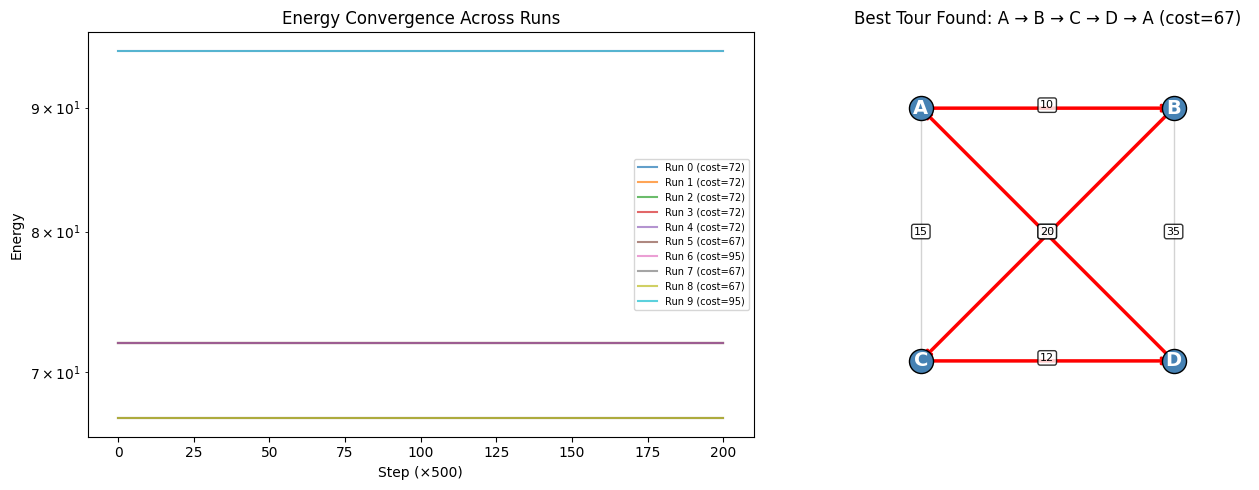

In [3]:
# Plot energy convergence for all runs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Energy convergence
ax = axes[0]
for run_idx, tour_str, cost, best_e, energies in results:
    label = f"Run {run_idx} (cost={cost})" if cost else f"Run {run_idx} (invalid)"
    ax.plot(energies, alpha=0.7, label=label)
ax.set_xlabel('Step (×500)')
ax.set_ylabel('Energy')
ax.set_title('Energy Convergence Across Runs')
ax.legend(fontsize=7)
ax.set_yscale('log')

# Plot the best tour on city coordinates
city_coords = {0: (0, 1), 1: (1, 1), 2: (0, 0), 3: (1, 0)}  # A, B, C, D
ax = axes[1]

# Draw all edges with distances
for i in range(N):
    for j in range(i + 1, N):
        xi, yi = city_coords[i]
        xj, yj = city_coords[j]
        ax.plot([xi, xj], [yi, yj], 'lightgray', linewidth=1, zorder=1)
        mx, my = (xi + xj) / 2, (yi + yj) / 2
        ax.text(mx, my, str(dist[i, j]), fontsize=8, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Draw best tour
if valid:
    best = min(valid, key=lambda r: r[2])
    tour = []
    for c in best[1].split(' → ')[:-1]:  # exclude last (return to start)
        tour.append(city_names.index(c))
    for k in range(len(tour)):
        i, j = tour[k], tour[(k + 1) % len(tour)]
        xi, yi = city_coords[i]
        xj, yj = city_coords[j]
        ax.annotate('', xy=(xj, yj), xytext=(xi, yi),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2.5), zorder=2)

# Draw city nodes
for i, (x, y) in city_coords.items():
    ax.scatter(x, y, s=300, c='steelblue', zorder=3, edgecolors='black')
    ax.text(x, y, city_names[i], fontsize=14, ha='center', va='center',
            color='white', fontweight='bold', zorder=4)

ax.set_title(f'Best Tour Found: {best[1]} (cost={best[2]})')
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Conclusion

We formulated the 4-city Traveling Salesman Problem as an Ising model optimization:

- **Binary variables** $x_{i,p}$ encode which city is visited at each position in the tour
- **Energy function** combines the travel cost with quadratic penalty terms enforcing that each city appears exactly once and each position is filled by exactly one city
- **Simulated annealing** was used to minimize the energy by flipping individual binary variables, accepting uphill moves with probability $e^{-\Delta E / T}$ as the temperature $T$ slowly decreases

The Ising model successfully finds the **optimal tour A → B → C → D → A with cost 67** across multiple random initializations. The penalty weight $A=100$ is large enough relative to edge costs to keep solutions feasible (valid permutation matrices), while simulated annealing explores the energy landscape effectively for this small problem.

This approach demonstrates how combinatorial optimization problems can be mapped onto Ising models — the same framework used in quantum annealing hardware (e.g., D-Wave systems) and Boltzmann machines in deep learning.